# 1.1.4 Measure of Frequency and Central Tendency

## Related readings :
- <a href="https://medium.com/@chelseaparlett/the-central-limit-theorem-clear-statistics-278b80fd6f9f">The Central Limit Theorem</a>
- <a href="https://medium.com/@ishitaguharoy/statistics-101-measures-of-central-tendency-fe9aeca2b7e7">Statistics 101- Measures of Central Tendency</a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
def generate_data():
    # Normal distribution
    data_normal = np.random.normal(loc=0, scale=1, size=1000)

    # Skewed distribution
    data_skewed = np.random.exponential(scale=2, size=1000)

    # Bimodal distribution
    data_bimodal = np.concatenate([np.random.normal(loc=-2, scale=1, size=500), np.random.normal(loc=3, scale=1.5, size=500)])

    return data_normal, data_skewed, data_bimodal

In [5]:
def calculate_statistics(data):
    mean = np.mean(data)
    median = np.median(data)

    # scipy.stats.mode() finds the most frequently occurring EXACT value.
    # For continuous data almost every value is unique, so it just returns
    # (essentially) the smallest value in the sample - not the peak of the
    # distribution.

    # For continuous data, the mode should be the value where the
    # probability density is highest. We estimate the density with a
    # Gaussian KDE (same one used in the plot) and take its peak.
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 1000)
    density = kde(x_range)
    mode = x_range[np.argmax(density)]

    return mean, median, mode


In [6]:
def plot_data(data, title, mean, median, mode):
    plt.figure(figsize=(10, 6))

    # Plot histogram
    sns.histplot(data, bins=30, kde=False, color='skyblue', label='Histogram', stat='density')

    # Plot KDE
    sns.kdeplot(data, color='b', linewidth=2, label='KDE')

    # Plot Mean, Median, Mode
    plt.axvline(median, color='g', linestyle='-', linewidth=2, label=f'Median: {median:.2f}')
    plt.axvline(mean, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')
    plt.axvline(mode, color='k', linestyle='-', linewidth=2, label=f'Mode: {mode:.2f}')

    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()


Normal Distribution: Mean = 0.03, Median = 0.05, Mode = 0.06


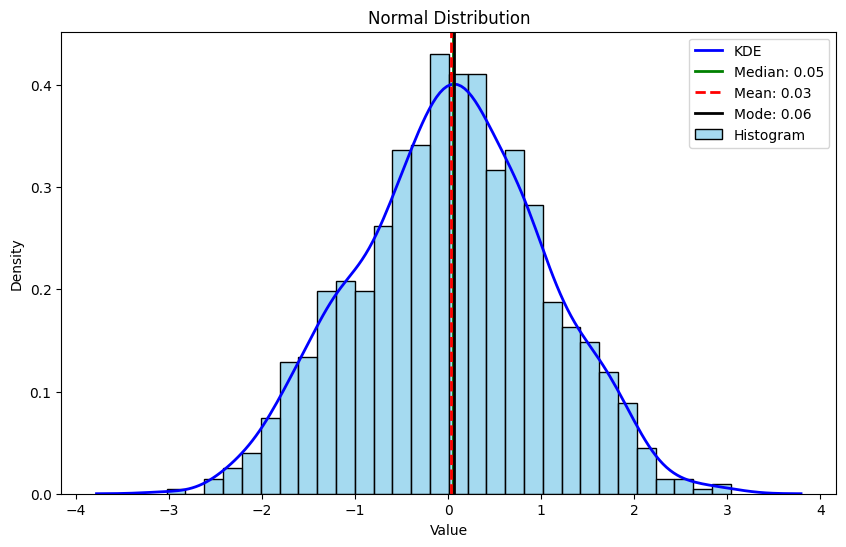

In [7]:
data_normal, data_skewed, data_bimodal = generate_data()

stats_normal = calculate_statistics(data_normal)
print("Normal Distribution: Mean = {:.2f}, Median = {:.2f}, Mode = {:.2f}".format(*stats_normal))
plot_data(data_normal, 'Normal Distribution', *stats_normal)

Skewed Distribution: Mean = 1.97, Median = 1.31, Mode = 0.67


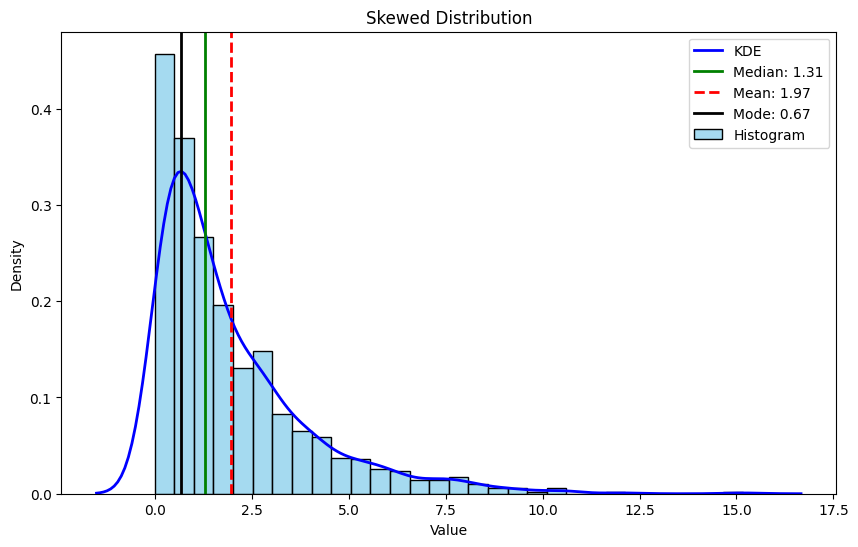

In [8]:
stats_skewed = calculate_statistics(data_skewed)
print("Skewed Distribution: Mean = {:.2f}, Median = {:.2f}, Mode = {:.2f}".format(*stats_skewed))
plot_data(data_skewed, 'Skewed Distribution', *stats_skewed)

Bimodal Distribution: Mean = 0.44, Median = -0.03, Mode = -1.98


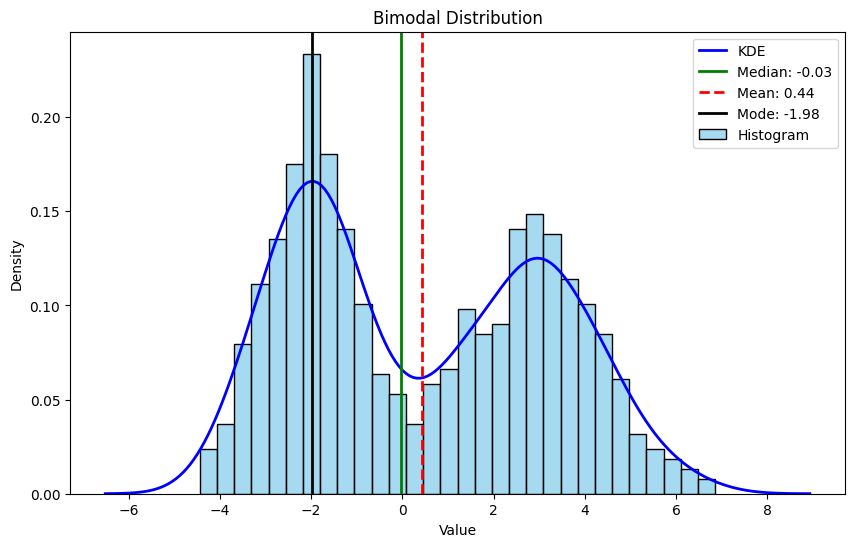

In [9]:
stats_bimodal = calculate_statistics(data_bimodal)
print("Bimodal Distribution: Mean = {:.2f}, Median = {:.2f}, Mode = {:.2f}".format(*stats_bimodal))
plot_data(data_bimodal, 'Bimodal Distribution', *stats_bimodal)

# Conclusion:

In this analysis, we generated three different types of data distributions: normal, skewed, and bimodal. We calculated the measures of central tendency (mean, median, and mode) for each distribution and visualized these distributions along with their central tendencies.

## Normal Distribution:
- The mean, median, and mode are very close to each other, which is characteristic of a normal distribution. The data is symmetrically distributed around the mean.

## Skewed Distribution:
- The data exhibits positive skewness, where the mean is greater than the median, and the median is greater than the mode. This indicates that a significant number of data points are concentrated on the left, with a long tail on the right.

## Bimodal Distribution:
- The data has two distinct peaks, indicating the presence of two different subpopulations. The mean, median, and mode provide different central tendency measures, which reflect the complexity of the bimodal distribution.

The visualizations using histograms and KDE plots effectively illustrated the distributions and their central tendencies. Such visualizations are crucial in understanding the underlying patterns in the data and making informed decisions based on statistical measures.

This analysis highlights the importance of using multiple measures of central tendency and visualizations to fully understand the nature of different data distributions.